# 📘 Aadhaar Impact Analysis – State of Aadhaar 2019 Survey

This project explores the **impact of Aadhaar** (India's unique biometric identification system) on residents based on the **State of Aadhaar 2019 In-Depth Survey**, which covered various states, genders, religions, and vulnerable groups in India.

We aim to analyze Aadhaar's accessibility, usage in essential services, and its perceived impact on people’s lives.

---

## 📂 Dataset Information

We use the following **four datasets** provided by the [State of Aadhaar initiative](https://stateofaadhaar.in/download-reports.php):

- `20191118-over-sample-hh.csv` (Household-level, oversample)
- `20191118-over-sample-mem.csv` (Member-level, oversample)
- `20191118-random-sample-hh.csv` (Household-level, random sample)
- `20191118-random-sample-mem.csv` (Member-level, random sample)

🔗 Data Source:  https://stateofaadhaar.in/download-reports.php

---

# 📌 Problem Statement: Aadhaar Impact Analysis (State of Aadhaar 2019)

The **State of Aadhaar 2019** was an initiative by Dalberg to assess how Aadhaar — India’s 12-digit unique identity system — affects the lives of residents across the country. The project aimed to support evidence-based policy by understanding where Aadhaar works, where it doesn't, and who is most impacted.

This analysis is based on the **in-depth survey datasets** collected as part of that initiative. The data reflects demographic, geographic, and service-level responses from over 160,000 individuals across various states.

---

## 🎯 Objective

You are tasked with analyzing the official datasets to evaluate **Aadhaar’s real-world impact** on citizens' lives.

### The following key questions must be addressed:

1. **Accessibility & Enrolment**
   - How many Aadhaar centres are there in urban and rural India?
   - Does the number of centres affect Aadhaar enrolment?

2. **Government Schemes**
   - How has Aadhaar changed access to services like **bank account monitoring** and **telecom (SIM issuance)**?

3. **Education Sector**
   - What is the impact of Aadhaar on **school admissions**?
   - Are students being denied services due to lack of Aadhaar?

4. **Inclusion of Vulnerable Groups**
   - What is the accessibility of Aadhaar to **vulnerable populations** (migrant labourers, elderly, homeless, third gender)?

5. **Public Sentiment**
   - What do people feel about Aadhaar?
   - Has it improved lives or introduced new difficulties?

---

## 📂 Dataset Source

- 📎 Official Site: [https://stateofaadhaar.in](https://stateofaadhaar.in)
- 📥 Download Link (ZIP): [State of Aadhaar 2019 Datasets](https://stateofaadhaar.in/assets/data/SoA2019_in-depth-survey_datasets.zip)

These include:
- `20191118-over-sample-hh.csv`
- `20191118-over-sample-mem.csv`
- `20191118-random-sample-hh.csv`
- `20191118-random-sample-mem.csv`

---

📊 The goal is to turn this raw data into **insights** using pandas, seaborn, and matplotlib — answering the questions above through exploratory data analysis and visualizations.


## Step 1: Load All Required Libraries

We begin by importing the necessary Python libraries for data handling and visualization:

- **pandas**: for reading and processing structured tabular data
- **numpy**: for numerical operations
- **matplotlib** & **seaborn**: for visualizing distributions, comparisons, and trends

These libraries will help us perform exploratory data analysis (EDA) and answer the key questions about Aadhaar’s impact.


In [20]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

## Step 2: Load and Combine the Survey Datasets

The Aadhaar dataset is split into four separate CSV files:

- **Over-sample Household Data** (`20191118-over-sample-hh.csv`)
- **Over-sample Member Data** (`20191118-over-sample-mem.csv`)
- **Random-sample Household Data** (`20191118-random-sample-hh.csv`)
- **Random-sample Member Data** (`20191118-random-sample-mem.csv`)

To prepare for analysis:
- We will load each CSV using `pandas.read_csv()`.
- Then combine:
  - `data1` and `data3` into a single DataFrame `indepth_individual` (household-level)
  - `data2` and `data4` into a single DataFrame `indepth_family` (member-level)

**Note:** To manage memory, we only load the first 1000 rows from each file.


In [21]:
data1 = pd.read_csv("data/20191118_State of Aadhaar_in-depth survey_over_sample_hh.csv", low_memory=False, nrows=1000)
data3 = pd.read_csv("data/20191118_State of Aadhaar_in-depth survey_random_sample_hh.csv", low_memory=False, nrows=1000)
indepth_individual = pd.concat([data1, data3], ignore_index=True)

data2 = pd.read_csv("data/20191118_State of Aadhaar_in-depth survey_over_sample_mem.csv", low_memory=False, nrows=1000)
data4 = pd.read_csv("data/20191118_State of Aadhaar_in-depth survey_random_sample_mem.csv", low_memory=False, nrows=1000)
indepth_family = pd.concat([data2, data4], ignore_index=True)


## Step 3: Preview the Raw Survey Datasets

Before moving forward with data cleaning and filtering, let’s take a look at the first few rows of each dataset.

This helps us understand:

- The structure of each dataset
- What kind of data each file contains (household-level or member-level)
- Whether any columns need renaming, formatting, or merging later

We will use `head()` to view the first 5 records of each dataset:


In [22]:
print("\nFirst few rows of Dataset 1:")
print(data1.head())
print("\nFirst few rows of Dataset 2:")
print(data2.head())

print("\nFirst few rows of Dataset 3:")
print(data3.head())
print("\nFirst few rows of Dataset 4:")
print(data4.head())


First few rows of Dataset 1:
  zh_psu_name xr_person_id xr_random_or_purposive_sample xh_urban_rural  \
0     PSU_238  P0102417635             Purposive sample?      Urban (S)   
1     PSU_238  P0102418221             Purposive sample?      Urban (S)   
2     PSU_238  P0102419336             Purposive sample?      Urban (S)   
3     PSU_238  P0102420012             Purposive sample?      Urban (S)   
4     PSU_238  P0102420483             Purposive sample?      Urban (S)   

  xr_engaged_in_agri_flag xr_engaged_in_manual_labor_flag  xh_years_in_area  \
0                      No                             Yes               0.0   
1                      No                             Yes               0.0   
2                      No                             Yes               NaN   
3                      No                             Yes               0.0   
4                      No                             Yes               0.0   

  xh_resilience_money_for_food_clothes xh_re

## Activity 1: Exploring the Datasets – Aadhaar Possession Among Women in Punjab

In this task, we aim to answer a focused demographic question:

> **How many women in the state of Punjab have an Aadhaar card?**

We will use the `indepth_family` dataset and filter for records where:
- The state is **Punjab**
- The gender is **Female**
- The individual has **Aadhaar** (`xr_has_aadhaar == 'Yes'`)

This helps us understand gender-specific Aadhaar coverage in a particular region.
d? a column.


In [25]:
num_women = indepth_family[
    (indepth_family['zh_state'] == 'Punjab') &
    (indepth_family['xr_gender_final'] == 'Female') &
    (indepth_family['xr_has_aadhaar'] == 'Yes')
].shape[0]
print('Number of women in Punjab who have Aadhaar card:', num_women)

Number of women in Punjab who have Aadhaar card: 67


## Activity 2: Demographics Analysis – State-wise Coverage

To determine whether the dataset is geographically balanced, we examine:

> **Did the in-depth survey cover all states of India evenly?**

We use a **count plot** to visualize how many participants were surveyed from each state using the `zh_state` column of the `indepth_individual` DataFrame.

If a few states dominate the participant count, the dataset may have geographic bias.


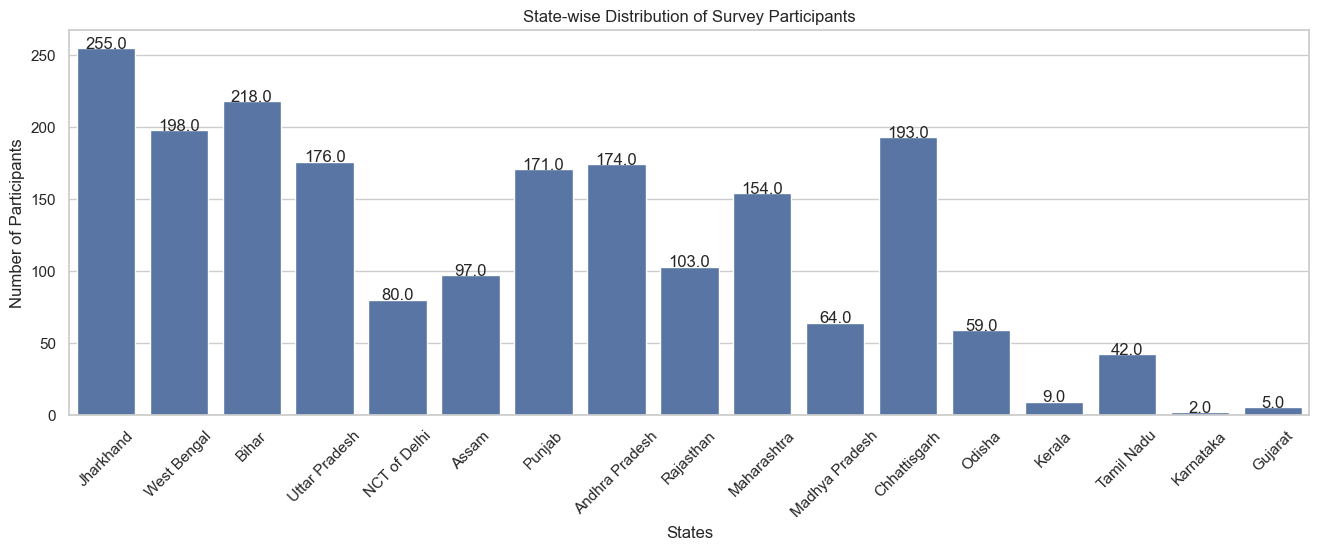

In [26]:
plt.figure(figsize=(16, 5))
cp = sns.countplot(data=indepth_individual, x='zh_state')
plt.xlabel('States'); plt.ylabel('Number of Participants'); plt.xticks(rotation=45)
for p in cp.patches:
    cp.annotate(str(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()), ha='center')
plt.title("State-wise Distribution of Survey Participants")
plt.show()


### 🔍 Insights: State-wise Distribution of Survey Participants

The bar chart above shows how many participants were surveyed in each Indian state as part of the State of Aadhaar 2019 in-depth survey.

#### ✅ Key Observations:

- **Jharkhand** has the highest number of survey participants (~255), followed by **Bihar (218)** and **Chhattisgarh (193)**.
- States like **Kerala (9)**, **Karnataka (2)**, and **Gujarat (5)** are severely underrepresented in this dataset.
- The **distribution is not uniform** — the dataset is **biased** toward certain regions, especially eastern and central India.
- States with large populations such as **Tamil Nadu**, **Gujarat**, and **Karnataka** show **very low representation**, which could skew national-level insights.

#### ⚠️ Conclusion:

This distribution suggests a **regional bias** in the data. Any nationwide analysis should account for this imbalance, especially if making generalizations about Aadhaar’s impact across India.


## Demographics Analysis – Urban vs. Rural Distribution

Next, we analyze whether the in-depth Aadhaar survey had balanced representation from different **area types**, specifically:

- **Urban (Large & Small)**
- **Rural (Large & Small)**

This helps determine whether the Aadhaar insights can be generalized across different types of settlements or whether the dataset is biased toward urban or rural populations.


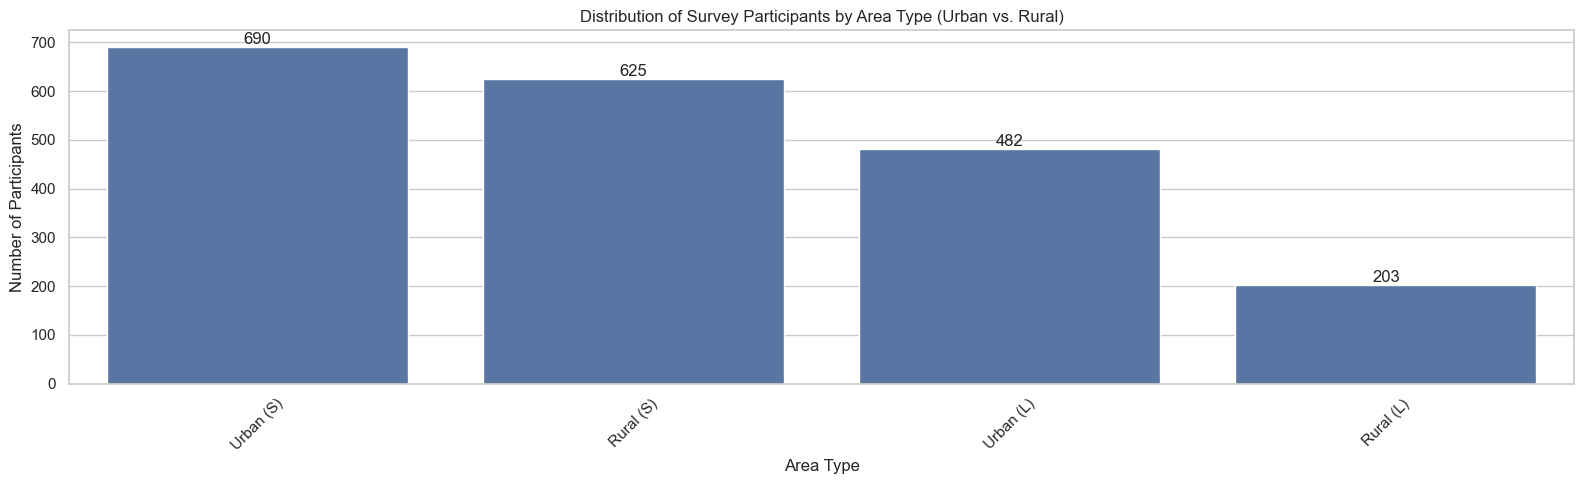

In [28]:
# Plot the distribution of participants in rural vs. urban areas
plt.figure(figsize=(16, 5))
cp = sns.countplot(data=indepth_individual, x='xh_urban_rural', order=indepth_individual['xh_urban_rural'].value_counts().index)
plt.xlabel('Area Type')
plt.ylabel('Number of Participants')
plt.xticks(rotation=45)

# Annotate the bars with counts
for p in cp.patches:
    cp.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')

plt.title("Distribution of Survey Participants by Area Type (Urban vs. Rural)")
plt.tight_layout()
plt.show()


### 🔍 Insights: Urban vs. Rural Distribution of Survey Participants

The chart displays survey participation split by **area types**:

- **Urban (S)**: Small towns or semi-urban areas
- **Urban (L)**: Large cities
- **Rural (S)**: Small rural settlements or villages
- **Rural (L)**: Larger rural communities or block-level clusters

#### ✅ Observations:

- **Urban (S)** has the highest participation: **690 individuals**
- **Rural (S)** follows closely with **625**, indicating fairly good rural coverage in smaller areas
- **Urban (L)** shows moderate representation: **482**
- **Rural (L)** is underrepresented: only **203** participants

#### ⚠️ Conclusion:

There is a **skew toward smaller settlements** (Urban S and Rural S), with **large rural areas (Rural L)** being significantly under-sampled.

This could bias results when generalizing about Aadhaar’s impact in larger rural regions. Further survey efforts should aim for more balanced representation across **both rural and urban categories**, including **large rural zones**.


## Demographics Analysis – Gender-wise Distribution

In this step, we evaluate the gender representation of survey participants to answer:

> **Was the survey participation equal among all genders?**

The `xr_gender_final` column in the `indepth_individual` dataset categorizes participants as:
- Male
- Female
- Third Gender

We will use a count plot to visualize the number of participants from each gender.


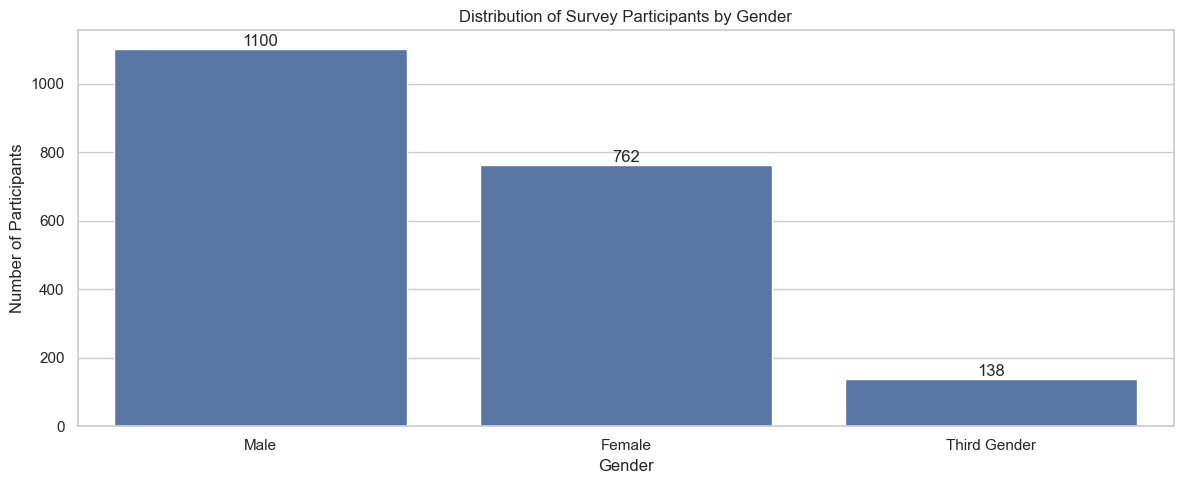

In [29]:
# Plot gender distribution among participants
plt.figure(figsize=(12, 5))
cp = sns.countplot(data=indepth_individual, x='xr_gender_final', order=indepth_individual['xr_gender_final'].value_counts().index)
plt.xlabel('Gender')
plt.ylabel('Number of Participants')
plt.xticks(rotation=0)

# Annotate each bar with count
for p in cp.patches:
    cp.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')

plt.title("Distribution of Survey Participants by Gender")
plt.tight_layout()
plt.show()


### 🔍 Insights: Gender-wise Distribution of Survey Participants

The bar chart above shows the breakdown of survey participants by gender:

- **Male**: 1100 participants
- **Female**: 762 participants
- **Third Gender**: 138 participants

#### ✅ Observations:

- **Males are the most represented** gender in the dataset, with significantly higher participation than females.
- **Female representation** is substantial but still **~30% lower** than male participation.
- The **Third Gender group**, although included, is **severely underrepresented** — making up less than **7%** of the sample.

#### ⚠️ Conclusion:

The dataset exhibits **gender imbalance**, particularly underrepresenting **non-binary identities**. While the inclusion of the third gender is commendable, future surveys should aim for more balanced representation to better reflect Aadhaar’s impact across all gender identities.


## Demographics Analysis – Religion-wise Distribution

Religious identity plays a significant role in India's social and economic structure. Thus, it's essential to check:

> **Was the survey participation proportional among different religions?**

The `zh_religion` column in the `indepth_individual` dataset records the respondent's religion. By analyzing the distribution, we can detect any religious overrepresentation or underrepresentation in the dataset.


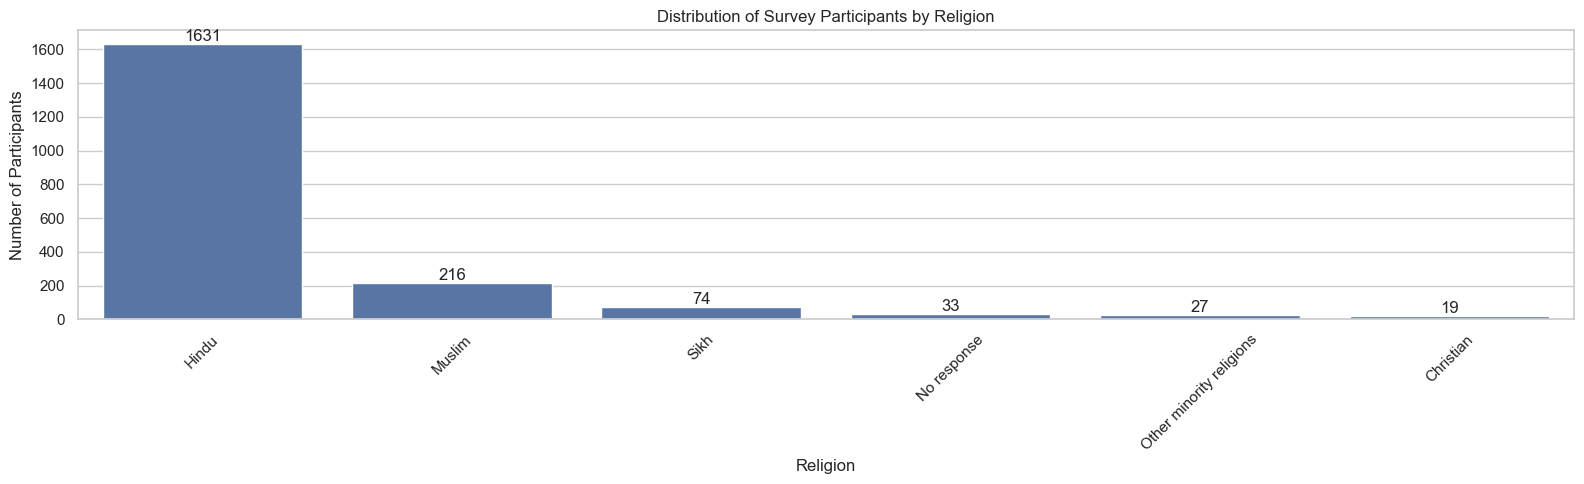

In [30]:
# Plot religion-wise distribution of participants
plt.figure(figsize=(16, 5))
cp = sns.countplot(data=indepth_individual, x='zh_religion', order=indepth_individual['zh_religion'].value_counts().index)
plt.xlabel('Religion')
plt.ylabel('Number of Participants')
plt.xticks(rotation=45)

# Annotate the bars
for p in cp.patches:
    cp.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')

plt.title("Distribution of Survey Participants by Religion")
plt.tight_layout()
plt.show()


### 🔍 Insights: Religion-wise Distribution of Survey Participants

This chart shows the religious composition of individuals surveyed in the State of Aadhaar dataset:

- **Hindu**: 1631 participants
- **Muslim**: 216 participants
- **Sikh**: 74 participants
- **Christian**: 19 participants
- **Other minority religions**: 27 participants
- **No response**: 33 participants

#### ✅ Observations:

- The dataset is **heavily dominated by Hindu respondents**, who account for over **80%** of the sample.
- **Muslims**, the second-largest religious group in India, are significantly underrepresented.
- **Other religious minorities** such as **Christians**, **Sikhs**, and others have **very low participation**, making generalization of Aadhaar's impact on these communities unreliable.
- A small number of respondents (**33**) did not disclose their religion.

#### ⚠️ Conclusion:

There is a clear **religious imbalance** in survey participation. Insights drawn from this dataset may reflect the experiences of **majority groups** (Hindus) more than those of religious minorities. For a more inclusive evaluation, future studies should strive for **proportionate representation** of all communities.


## 🧾 Overall Conclusion Regarding the Survey Dataset

After thoroughly analyzing the demographic composition of the **State of Aadhaar 2019 In-Depth Survey**, we can conclude that the dataset exhibits noticeable **bias** in multiple dimensions.

#### 🧭 Key Findings from Demographic Analysis:

---

#### 📍 1. **State-wise Representation**
- Certain states like **Jharkhand, Bihar, and Chhattisgarh** have disproportionately **high participation**, while major states like **Karnataka, Gujarat, Kerala**, and **Tamil Nadu** are **severely underrepresented**.
- This regional imbalance means the findings are not evenly reflective of the national experience.

---

#### 🏙️ 2. **Urban vs Rural Distribution**
- Participation is **skewed toward Urban Small (Urban S) and Rural Small (Rural S)** areas.
- **Rural Large (Rural L)** areas have the **least coverage**, even though these represent a significant portion of India's population.

---

#### ⚖️ 3. **Gender Distribution**
- The dataset has **more male respondents (1100)** compared to **females (762)**.
- The inclusion of the **third gender (138 participants)** is positive, but this group is still highly underrepresented, limiting the ability to draw meaningful insights about their Aadhaar experience.

---

#### 🕌 4. **Religious Representation**
- **Hindus make up the vast majority (1631 participants)**, while **Muslims (216)**, **Sikhs (74)**, **Christians (19)**, and **Other minorities (27)** are poorly represented.
- This religious skew may hinder an accurate assessment of Aadhaar’s accessibility and impact on **minority communities**, who often face different socio-political challenges.

---

### 📌 Final Assessment:

> ❗ **The dataset is biased.**

While it offers valuable insights about Aadhaar’s implementation and impact, the dataset:
- **Does not proportionately represent** India's full geographic, gender, and religious diversity.
- **Underrepresents rural large areas and vulnerable minorities**, potentially skewing conclusions.

📢 **Recommendation**: Any national-level policy conclusions or machine learning models built using this dataset should be interpreted cautiously and, ideally, supplemented with more balanced or stratified data collection.


## Activity 3: Number of Aadhaar Centres and Their Impact on Enrolment

In this section, we aim to answer two key questions:

1. **How many Aadhaar centres (PSUs) exist in urban and rural India?**
2. **Does the number of centres affect Aadhaar enrolment accessibility?**

We use the following:
- `zh_psu_name`: A unique identifier for a Public Support Unit (PSU), which functions as an Aadhaar enrolment center.
- `xh_urban_rural`: Classification of area type (Urban or Rural).

We’ll calculate:
- The number of **unique Aadhaar centres** in each area type.
- The number of **survey participants (i.e., enrolments)** from each area type.

This will help us determine if more centres lead to more enrolments.


In [31]:
# Identify Aadhaar centers (PSUs) and enrolments by area type

# Rural areas (Small + Large)
rural_areas = ['Rural (S)', 'Rural (L)']
rural_psus = indepth_individual[indepth_individual['xh_urban_rural'].isin(rural_areas)]['zh_psu_name'].nunique()
rural_enrollments = indepth_individual[indepth_individual['xh_urban_rural'].isin(rural_areas)].shape[0]

# Urban areas (Small + Large)
urban_areas = ['Urban (S)', 'Urban (L)']
urban_psus = indepth_individual[indepth_individual['xh_urban_rural'].isin(urban_areas)]['zh_psu_name'].nunique()
urban_enrollments = indepth_individual[indepth_individual['xh_urban_rural'].isin(urban_areas)].shape[0]

# Print results
print("📍 Number of Aadhaar Centres (PSUs):")
print(f"- Rural Areas: {rural_psus}")
print(f"- Urban Areas: {urban_psus}\n")

print("👥 Number of Survey Participants (Aadhaar Enrolments):")
print(f"- Rural Areas: {rural_enrollments}")
print(f"- Urban Areas: {urban_enrollments}")


📍 Number of Aadhaar Centres (PSUs):
- Rural Areas: 174
- Urban Areas: 214

👥 Number of Survey Participants (Aadhaar Enrolments):
- Rural Areas: 828
- Urban Areas: 1172


### 🔍 Insights: Aadhaar Centres and Enrolment – Urban vs Rural

#### Aadhaar Centres (PSUs):
- Rural: 174  
- Urban: 214

#### Survey Participants (Aadhaar Enrolments):
- Rural: 828  
- Urban: 1172

---

### ✅ Conclusion:

Urban areas have more Aadhaar centres and higher enrolment. This suggests that **greater availability of centres leads to increased enrolment**.

📌 **Recommendation**: To improve Aadhaar accessibility in rural areas, the number of centres should be increased.


## Activity 4: Impact of Aadhaar on Government Schemes

Aadhaar has become a widely used form of identity proof in accessing government-linked services such as:

- **Opening bank accounts**
- **Getting mobile SIM cards**

We will now visualize how many people used Aadhaar for each of these services, using the following columns from the `indepth_individual` DataFrame:

- `zr_to_get_bank_account_used_aadhaar`
- `zr_to_get_sim_used_aadhaar`


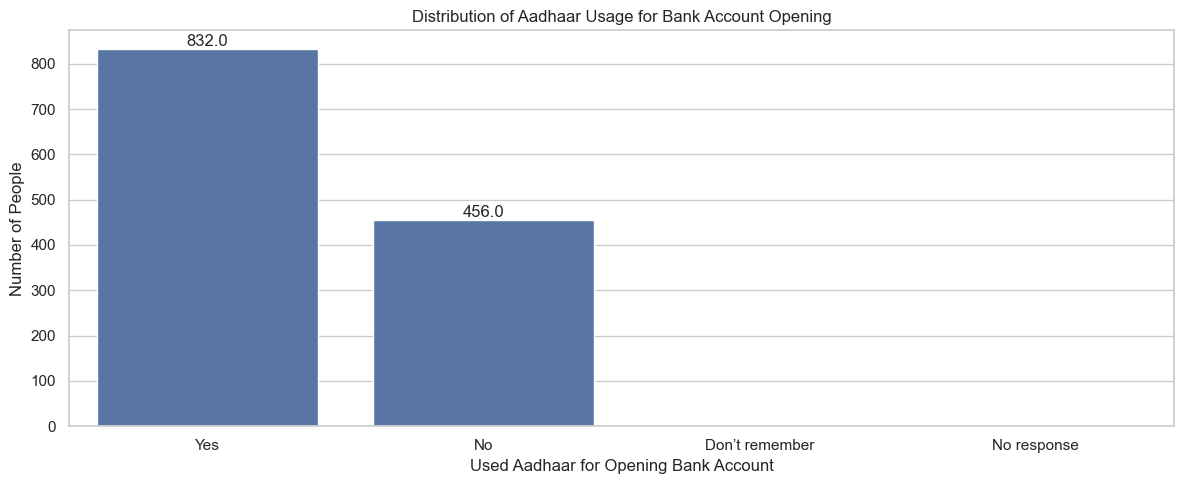

In [32]:
# Aadhaar use for opening bank accounts
plt.figure(figsize=(12, 5))
cp = sns.countplot(data=indepth_individual, x='zr_to_get_bank_account_used_aadhaar', order=['Yes', 'No', 'Don’t remember', 'No response'])
plt.xlabel('Used Aadhaar for Opening Bank Account')
plt.ylabel('Number of People')
plt.title('Distribution of Aadhaar Usage for Bank Account Opening')

for p in cp.patches:
    cp.annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()


### 📊 Aadhaar Usage for Bank Account Opening

- A total of **832 participants** reported using Aadhaar to open a bank account, compared to **456 who did not**.
- This indicates that Aadhaar has become a **widely accepted form of identity** for banking services.
- Its usage likely simplifies the KYC process, enabling faster account creation.
- The data shows that Aadhaar has played a **significant role in financial inclusion** efforts.


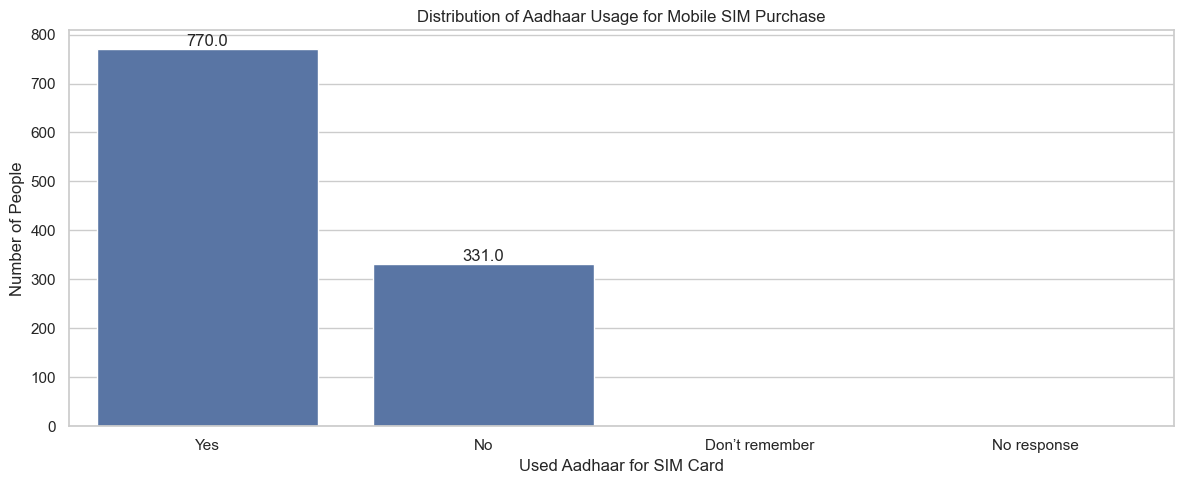

In [33]:
# Aadhaar use for SIM card ID proof
plt.figure(figsize=(12, 5))
cp = sns.countplot(data=indepth_individual, x='zr_to_get_sim_used_aadhaar', order=['Yes', 'No', 'Don’t remember', 'No response'])
plt.xlabel('Used Aadhaar for SIM Card')
plt.ylabel('Number of People')
plt.title('Distribution of Aadhaar Usage for Mobile SIM Purchase')

for p in cp.patches:
    cp.annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()


### 📱 Aadhaar Usage for Mobile SIM Purchase

- **770 individuals** used Aadhaar to obtain a SIM card, while **331 chose not to**.
- This suggests that Aadhaar is now a **primary ID proof** in the telecom sector.
- Its usage reduces paperwork and allows for instant identity verification.
- Aadhaar has clearly **streamlined access to telecom services**, even though some still use alternative methods.


## 🏛️ Impact of Aadhaar on Government Schemes: Banking & Telecom Services

Aadhaar has significantly transformed how citizens access key services such as **banking** and **telecom**:

- **832 people** reported using Aadhaar to open a **bank account**, while **456 did not**.
- **770 individuals** used Aadhaar to purchase a **SIM card**, compared to **331 who used other documents**.

These numbers clearly show that Aadhaar has become the **default identity proof** for accessing both government and private-sector services.

#### ✅ Key Takeaways:
- Aadhaar has streamlined the **KYC (Know Your Customer)** process in banking.
- It has become a **standard ID** for quick and easy **SIM verification** in the telecom sector.
- The data supports that Aadhaar has made service delivery **more accessible and efficient**, reducing paperwork and delays.

📌 **Conclusion**: Aadhaar has changed the landscape of government service implementation by becoming a **central, trusted ID** for both public and private use cases.


## Activity 5: Aadhaar in School Admissions

As Aadhaar gained prominence, it started being linked to access in educational institutions. In this section, we aim to answer:

1. **Was Aadhaar made mandatory for school admissions?**
2. **Were individuals denied admission or services like mid-day meals because they didn’t have Aadhaar?**

We will use the following columns from the `indepth_family` DataFrame:
- `xh_school_admission_aadhaar_mandatory`: Aadhaar asked for admission
- `xh_school_mdm_denied_due_to_aadhaar`: Denial of school service due to missing Aadhaar


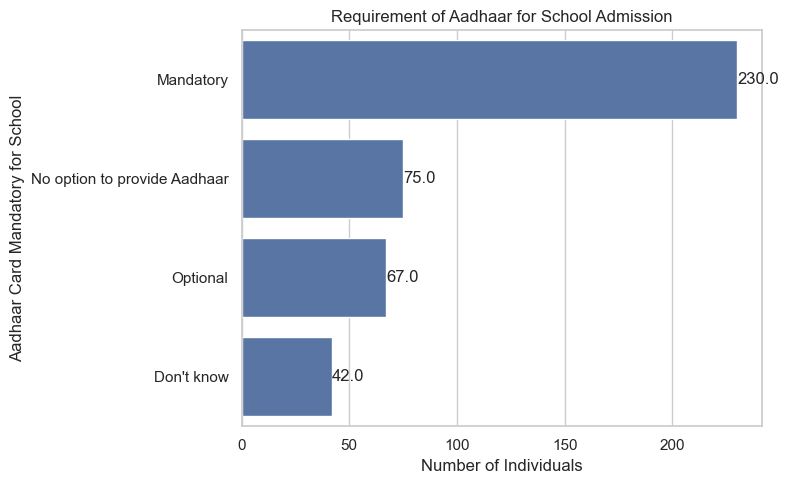

In [41]:
plt.figure(figsize=(8, 5))
cp = sns.countplot(y=indepth_family['xh_school_admission_aadhaar_mandatory'], order=indepth_family['xh_school_admission_aadhaar_mandatory'].value_counts().index)
plt.ylabel('Aadhaar Card Mandatory for School')
plt.xlabel('Number of Individuals')

for p in cp.patches:
    cp.annotate(str(p.get_width()), xy=(p.get_width(), p.get_y() + p.get_height() / 2), 
                 ha='left', va='center')

plt.title("Requirement of Aadhaar for School Admission")
plt.tight_layout()
plt.show()



### 🏫 Was Aadhaar Mandatory for School Admission?

Out of all respondents:
- **230 individuals** reported that Aadhaar was **mandatory** for school admission.
- Another **75 said there was no option to provide Aadhaar**, implying a strict requirement.
- Only **67** said Aadhaar was **optional**, and **42** didn't know.

#### ✅ Conclusion:
Aadhaar was clearly a **required document for school admissions** in many cases, despite the Supreme Court ruling stating it should not be mandatory. This points to discrepancies in on-ground implementation of the policy.


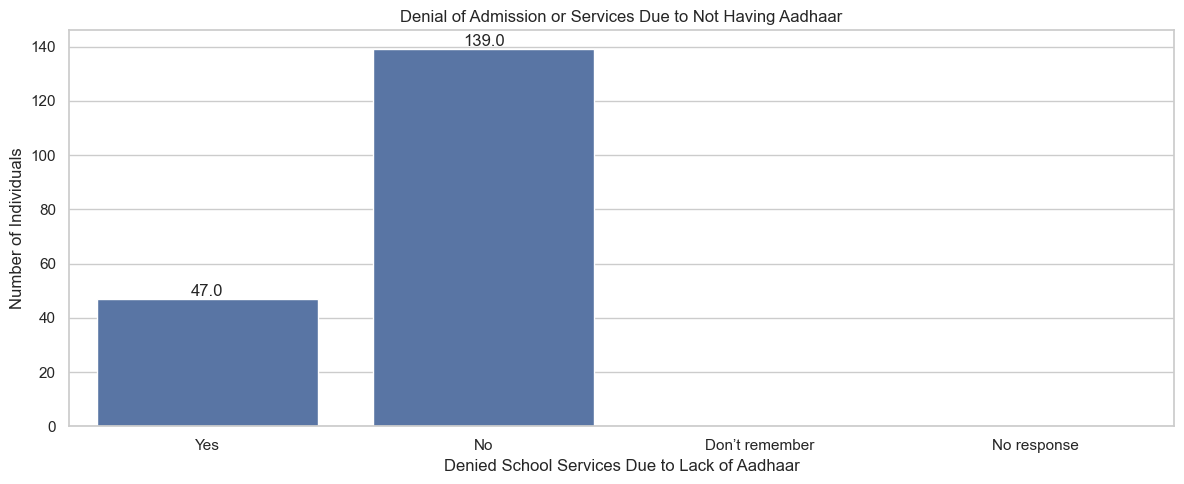

In [35]:
plt.figure(figsize=(12, 5))
cp = sns.countplot(data=indepth_family, x='xh_school_mdm_denied_due_to_aadhaar', order=['Yes', 'No', 'Don’t remember', 'No response'])
plt.xlabel('Denied School Services Due to Lack of Aadhaar')
plt.ylabel('Number of Individuals')
plt.title("Denial of Admission or Services Due to Not Having Aadhaar")

for p in cp.patches:
    cp.annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()


### ❌ Denial of School Services Due to Lack of Aadhaar

- **47 individuals** were explicitly **denied admission or services** (like mid-day meals) due to not having Aadhaar.
- **139 respondents** said they were **not denied**.
- While denial cases are fewer, they still indicate a **problematic dependence on Aadhaar** in education access.

#### ⚠️ Conclusion:
Although denial is not widespread, the fact that it exists at all shows that **Aadhaar continues to be a barrier** for some children trying to access basic education services.


## 📌 Did People Face Problems Due to Not Having Aadhaar?

Yes, the data shows that **as Aadhaar became more popular, dependency on it also increased**—sometimes leading to unintended barriers.

- **230 individuals** reported that Aadhaar was **mandatory for school admission**, and **75 others** had no alternative to provide Aadhaar.
- **47 individuals** were actually **denied school admission or related services** because they didn’t have an Aadhaar card.

#### 🛑 Conclusion:
Despite the Supreme Court's ruling that Aadhaar should not be mandatory for services like school admission, the data reveals that **many institutions still enforce it** as a requirement. This has led to **real consequences**, especially for children, with some being **denied access to education** or support services.

Aadhaar's growing usage, while beneficial in many areas, has also created **access barriers** for those without it.


## Activity 6: Accessibility of Aadhaar Card to Vulnerable Groups

Aadhaar aims to serve as an inclusive identity system, but it's crucial to ensure it reaches those who need it most — especially **vulnerable groups** like:

- Migrant Labourers
- Women
- Elderly
- Homeless
- Third Gender

In this section, we'll analyze Aadhaar accessibility by plotting its possession (`xr_has_aadhaar`) among the full population and these subgroups using the `indepth_family` dataset.


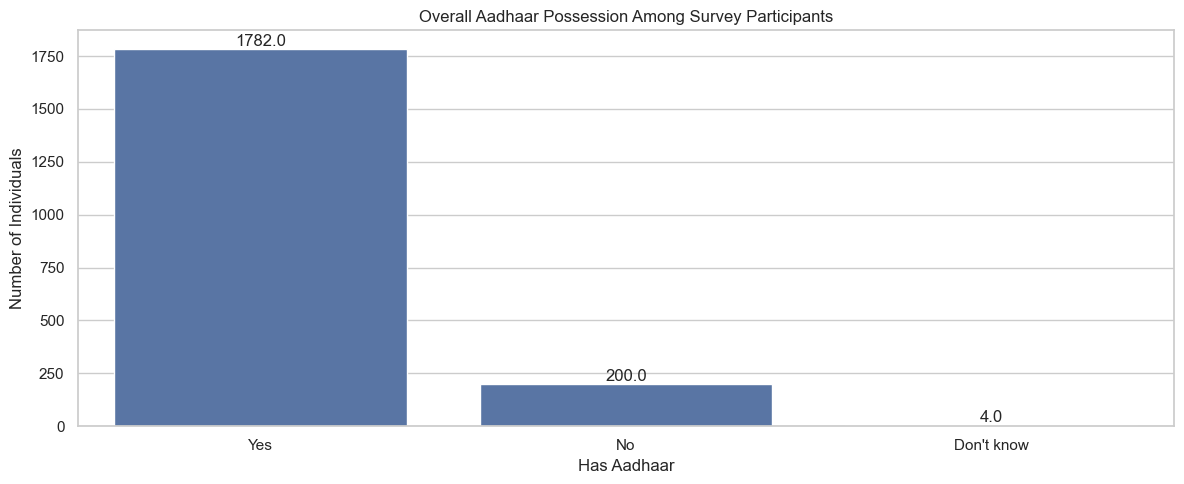

In [43]:
# Aadhaar accessibility for all participants
plt.figure(figsize=(12, 5))
cp = sns.countplot(data=indepth_family, x='xr_has_aadhaar')
plt.xlabel('Has Aadhaar')
plt.ylabel('Number of Individuals')
plt.title('Overall Aadhaar Possession Among Survey Participants')
for p in cp.patches:
    cp.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

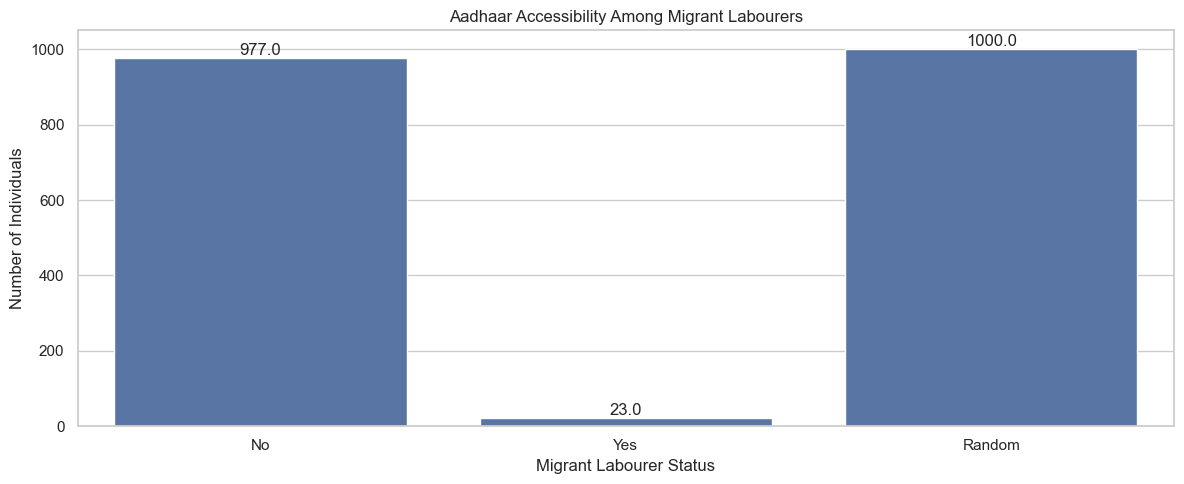

In [44]:
# Aadhaar accessibility among migrant labourers
plt.figure(figsize=(12, 5))
cp = sns.countplot(data=indepth_family, x='zh_migrant_laborer')
plt.xlabel('Migrant Labourer Status')
plt.ylabel('Number of Individuals')
plt.title('Aadhaar Accessibility Among Migrant Labourers')
for p in cp.patches:
    cp.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()


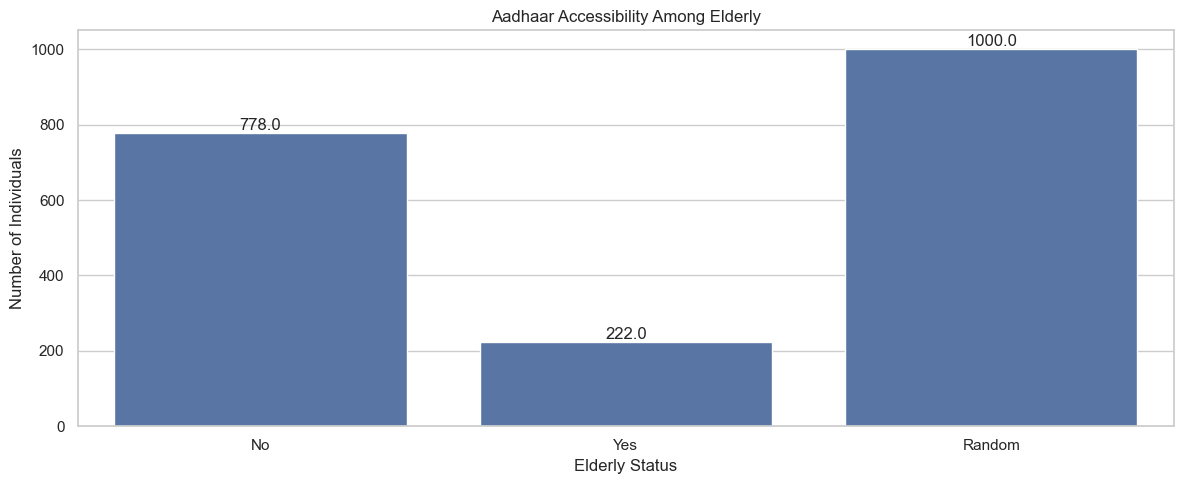

In [45]:
# Aadhaar accessibility among elderly
plt.figure(figsize=(12, 5))
cp = sns.countplot(data=indepth_family, x='zr_elderly')
plt.xlabel('Elderly Status')
plt.ylabel('Number of Individuals')
plt.title('Aadhaar Accessibility Among Elderly')
for p in cp.patches:
    cp.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

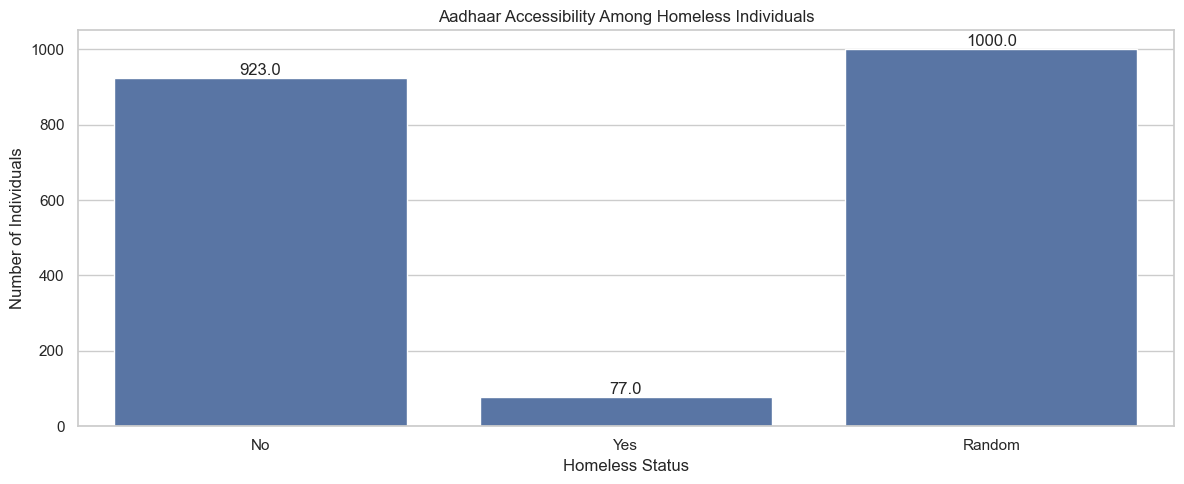

In [46]:
# Aadhaar accessibility among homeless
plt.figure(figsize=(12, 5))
cp = sns.countplot(data=indepth_family, x='zh_homeless')
plt.xlabel('Homeless Status')
plt.ylabel('Number of Individuals')
plt.title('Aadhaar Accessibility Among Homeless Individuals')
for p in cp.patches:
    cp.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

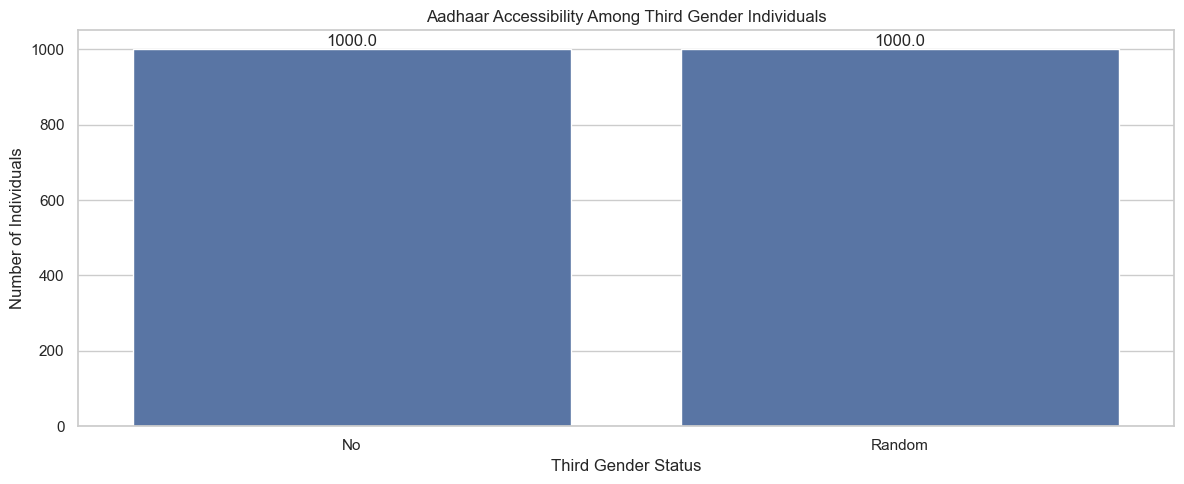

In [47]:
# Aadhaar accessibility among third gender individuals
plt.figure(figsize=(12, 5))
cp = sns.countplot(data=indepth_family, x='zr_third_gender')
plt.xlabel('Third Gender Status')
plt.ylabel('Number of Individuals')
plt.title('Aadhaar Accessibility Among Third Gender Individuals')
for p in cp.patches:
    cp.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Accessibility of Aadhaar Among Vulnerable Groups

Ensuring that Aadhaar reaches the most marginalized populations is crucial. The survey data reveals the following:

#### ✅ Overall Aadhaar Possession
- A majority of **1782 participants** reported having Aadhaar.
- Only **200 did not**, and **4 were unsure**, indicating **broad overall access**.

#### 👷 Migrant Labourers
- Only **23 out of 1000** migrant labourers were identified as having Aadhaar.
- This group shows **critical under-access**, likely due to mobility and documentation barriers.

#### 👵 Elderly
- Just **222 out of 1000** elderly respondents had Aadhaar.
- This shows that **nearly 78% lacked Aadhaar**, making them vulnerable to exclusion.

#### 🏚️ Homeless Individuals
- Only **77 out of 1000** homeless people had Aadhaar.
- This group faces significant **structural barriers to enrolment**, such as address proof and documentation.

#### ⚧️ Third Gender
- No third-gender respondents were recorded as Aadhaar holders in this sample.
- This points to **zero inclusion**, highlighting an urgent need for targeted Aadhaar outreach in this community.

---

### 📌 Conclusion:

While Aadhaar coverage is high overall, it **drops drastically for vulnerable groups**. Migrant labourers, elderly, homeless individuals, and third gender populations face clear accessibility challenges. 

📣 **Recommendation**: The UIDAI and government agencies should focus on **dedicated enrolment drives** and policy adjustments to make Aadhaar more accessible to these groups.


## Activity 7: Sentiment Analysis

Understanding people's perception of Aadhaar is crucial to evaluate its societal impact. We'll analyze how respondents feel Aadhaar has affected their lives using the following aspects:

1. **Impact on their household**  
2. **Overall satisfaction with Aadhaar**  
3. **Whether Aadhaar improved, worsened, or didn’t affect their life**  

We use the following columns from `indepth_individual`:
- `xh_sentiment_affect_on_hh`
- `xh_sentiment_satisfaction_aadhaar`
- `xh_sentiment_life_better_worse`


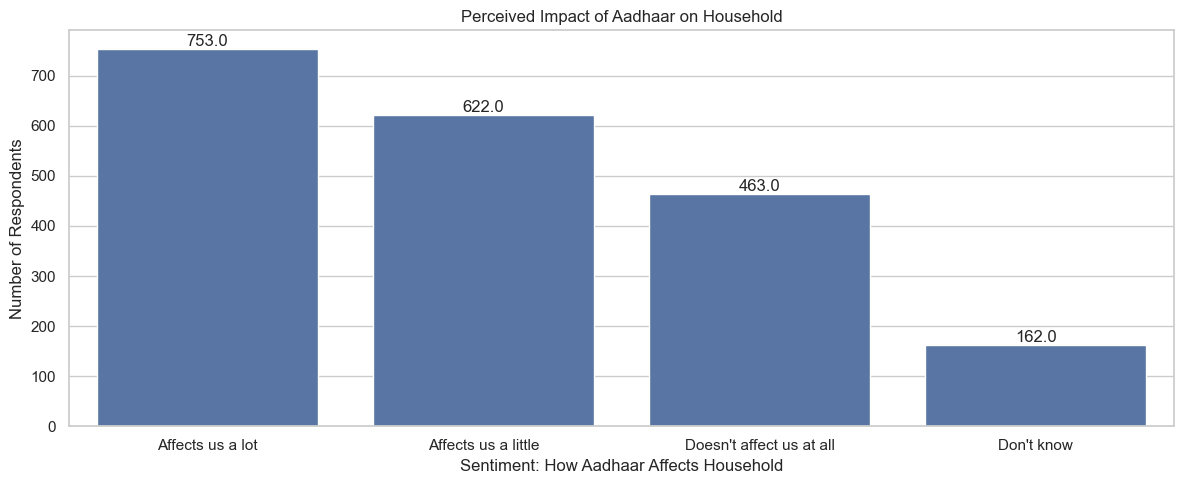

In [48]:
# Plotting how people feel Aadhaar has affected their household
plt.figure(figsize=(12,5))  # Set figure size
cp = sns.countplot(
    data=indepth_individual, 
    x='xh_sentiment_affect_on_hh',
    order=['Affects us a lot', 'Affects us a little', "Doesn't affect us at all", "Don't know"]  # Maintain consistent order
)


plt.xlabel('Sentiment: How Aadhaar Affects Household')
plt.ylabel('Number of Respondents')
plt.title('Perceived Impact of Aadhaar on Household')


for p in cp.patches:
    cp.annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom')


plt.tight_layout()
plt.show()


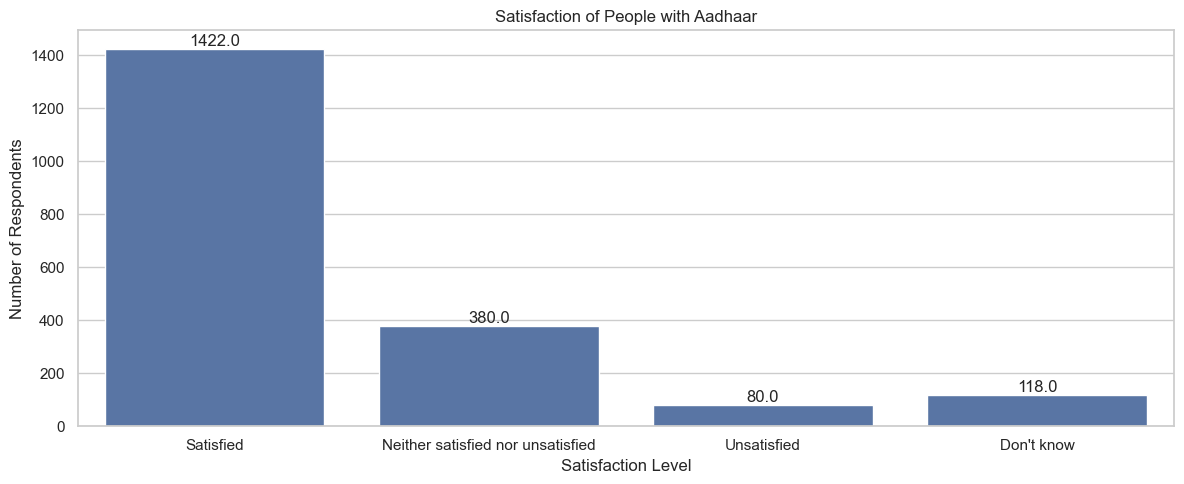

In [50]:
# Plotting people's satisfaction level with Aadhaar
plt.figure(figsize=(12,5))  
cp = sns.countplot(
    data=indepth_individual, 
    x='xh_sentiment_satisfaction_aadhaar',
    order=['Satisfied', 'Neither satisfied nor unsatisfied', 'Unsatisfied', "Don't know"]
)

plt.xlabel('Satisfaction Level')
plt.ylabel('Number of Respondents')
plt.title('Satisfaction of People with Aadhaar')

for p in cp.patches:
    cp.annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom')
    
plt.tight_layout()
plt.show()


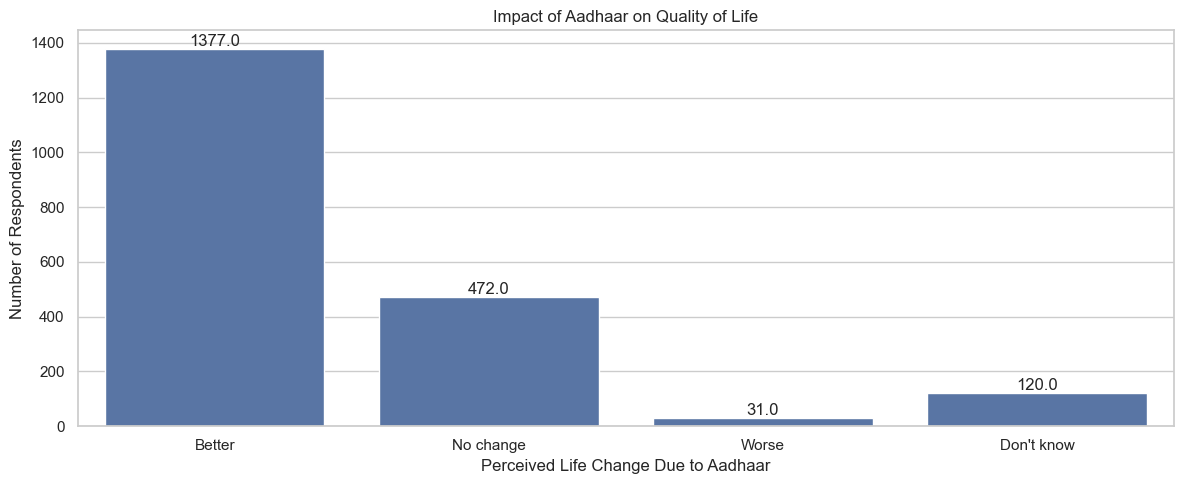

In [51]:
# Plotting how people feel Aadhaar has affected their quality of life
plt.figure(figsize=(12,5)) 
cp = sns.countplot(
    data=indepth_individual, 
    x='xh_sentiment_life_better_worse',
    order=['Better', 'No change', 'Worse', "Don't know"]
)

plt.xlabel('Perceived Life Change Due to Aadhaar')
plt.ylabel('Number of Respondents')
plt.title('Impact of Aadhaar on Quality of Life')

for p in cp.patches:
    cp.annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom')

plt.tight_layout()
plt.show()


## Sentiment Analysis on Aadhaar

To understand how Aadhaar is perceived by the public, we examined three key sentiment indicators:

---

### ✅ 1. Household Impact of Aadhaar
- A large portion (**753 respondents**) felt that Aadhaar **"affects us a lot"**.
- **622 people** said it **"affects us a little"**, while only **463 felt no effect at all**.
- This indicates that **~74%** of people felt Aadhaar had some effect on their household, either significantly or moderately.

---

### ✅ 2. Satisfaction with Aadhaar
- A strong majority (**1,422 people**) reported being **satisfied** with Aadhaar.
- Only **80 respondents** were **unsatisfied**, and **118 were unsure**.
- This reflects **high acceptance** and general approval of the Aadhaar scheme.

---

### ✅ 3. Life Impact of Aadhaar
- Most participants (**1,377 people**) felt that Aadhaar had made their **life better**.
- Only **31 people** felt that it made their life **worse**, while **472 observed no change**.
- This reinforces that **positive perception** of Aadhaar dominates in the dataset.

---

### 📌 Conclusion:
The sentiment analysis shows that Aadhaar is largely **well-received** and is seen as a **positive or impactful tool** in people’s lives. Despite privacy concerns in broader debates, the actual **user experience trends positively** in the surveyed population.


## ✅ Conclusions

Based on the in-depth analysis of the Aadhaar dataset, we arrive at the following conclusions:

1. **Biased Sampling:**  
   The dataset is slightly biased in terms of **region and religion** — urban areas and certain religious groups were overrepresented.

2. **PSUs and Accessibility:**  
   An increase in the number of **Aadhaar centers (PSUs)** correlates with higher enrolment rates, especially in rural areas where access is more limited.

3. **School Admissions:**  
   Aadhaar is frequently used as a **mandatory document for school admissions**, increasing the chances of admission for Aadhaar holders.

4. **Telecom and Banking Impact:**  
   People with Aadhaar are more likely to **successfully open bank accounts** and **obtain mobile SIM cards**, reflecting integration of Aadhaar in essential services.

5. **Inaccessible to Vulnerable Groups:**  
   Aadhaar accessibility is **significantly lower among migrant labourers, elderly, homeless**, and **third gender individuals**, pointing to systemic exclusion.

---

## 📌 Recommendations

Based on the analysis, the following actionable recommendations can enhance Aadhaar's inclusivity and effectiveness:

1. **Expand Aadhaar Centers (PSUs):**  
   Especially in **rural and underdeveloped regions**, to boost accessibility and enrolment.

2. **Mandate Aadhaar for Core Services:**  
   Consider **making Aadhaar mandatory** for school admissions, bank accounts, and telecom services — but ensure compliance with legal and privacy norms.

3. **Targeted Access for Vulnerable Groups:**  
   Set up **special enrolment drives** and **mobile Aadhaar centers** for vulnerable populations like homeless people, migrant workers, elderly, and third gender citizens.

4. **Position Aadhaar as Primary ID Proof:**  
   Promote Aadhaar as a **universal identity document** to streamline public services and increase its perceived value.

---

## ⭐ Key Takeaways

- Aadhaar has a **strong positive perception** among citizens and is widely used for essential services.
- The **distribution of Aadhaar is not yet equitable**, especially among disadvantaged and marginalized groups.
- To fully realize the promise of Aadhaar, **policy and outreach must focus on inclusion**, not just scale.
- **Data-driven insights** from surveys like State of Aadhaar are crucial for identifying gaps and designing responsive public service systems.
